4. Overfitting Experiement

In our model selection notebook we came to the conclusion that our CNN is the best choice. However in order to see if our model is not just doing well on the training data, because it rather memorize it instead of checking for general patterns. I'll coduct some tests in this notebook and see if the model is overfitting.

In this notebook we will try this techniques in order to test overfitting:
1. Dropout
2. Batch Normalization
3. L2 Regularization

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from data.dataset import Dataset
from models.cnn_builder import CNNBuilder

/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Dataset()
X, y = dataset.get_prep_data()

# Normalize the image data
X = X.astype("float32") / 255.0

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1))

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Number of classes: {y_train.shape[1]}")

Training set: 2000 samples
Test set: 500 samples
Input shape: (168, 120, 3)
Number of classes: 5


4.1 Helper Function

This helper function trains the model and returns the training history for plotting.

In [ ]:
def train_and_plot(builder, name, epochs=20):
    model = builder.build_model()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.15,
        verbose=0
    )
    print(f"{name}: val_loss={history.history['val_loss'][-1]:.4f}, val_acc={history.history['val_accuracy'][-1]:.4f}")
    return history

4.2 Experiments

In this section we will conduct the experiments to test for overfitting. We will start with a simple CNN and then add dropout, batch normalization and L2 regularization to see how it affects the performance.


In [5]:
histories = {}

# 1. Baseline
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
histories['Baseline'] = train_and_plot(builder, 'Baseline')

# 2. Dropout
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
builder.apply_dropout = True
histories['Dropout'] = train_and_plot(builder, 'Dropout')

# 3. Batch Normalization
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
builder.apply_batch_normalization = True
histories['BatchNorm'] = train_and_plot(builder, 'BatchNorm')

# 4. L2 Regularization
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
builder.apply_regularization = True
histories['L2'] = train_and_plot(builder, 'L2')

# 5. All combined
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
builder.apply_dropout = True
builder.apply_batch_normalization = True
builder.apply_regularization = True
histories['All Combined'] = train_and_plot(builder, 'All Combined')

Baseline: val_loss=1.3851393461227417, val_acc=0.7099999785423279
Dropout: val_loss=1.3628889322280884, val_acc=0.746666669845581
BatchNorm: val_loss=1.1761150360107422, val_acc=0.6766666769981384
L2: val_loss=1.254446268081665, val_acc=0.7300000190734863
All Combined: val_loss=1.016196370124817, val_acc=0.7433333396911621


4.3 Visualize Training vx Validation Loss

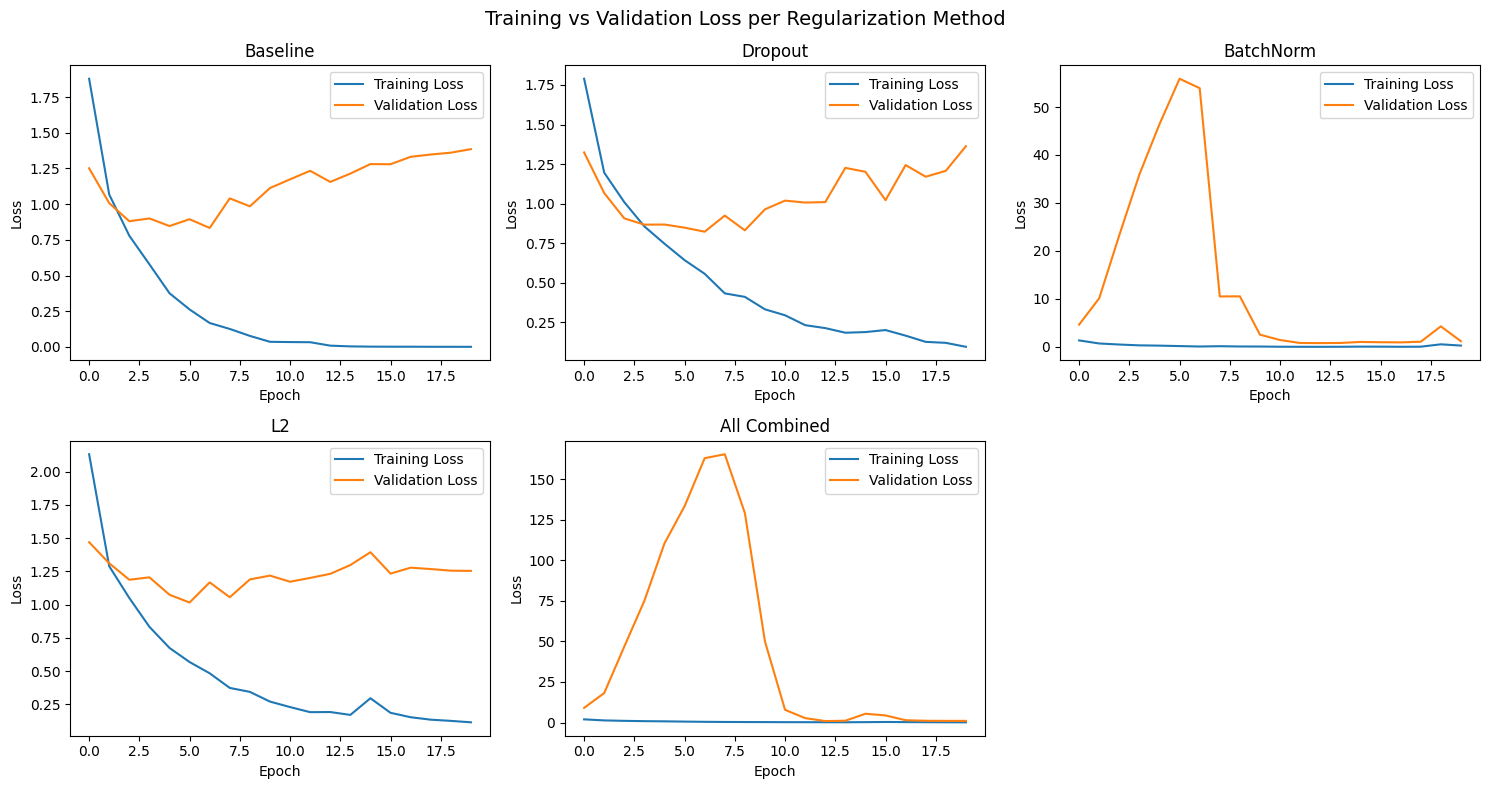

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, history) in enumerate(histories.items()):
    axes[i].plot(history.history['loss'], label='Training Loss')
    axes[i].plot(history.history['val_loss'], label='Validation Loss')
    axes[i].set_title(name)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

# Hide the 6th subplot
axes[5].set_visible(False)

plt.suptitle('Training vs Validation Loss per Regularization Method', fontsize=14)
plt.tight_layout()
plt.show()

From these plots we can see that our model is overfitting. The training loss gets smaller after each epoch and the validation loss gets bigger. This gap is an indication, that the model is rather memorizing the dataset instead of recognizing patterns. The dropout technique didn't had a big impact, also the L2 technique is still overfitting, but it is slighlty more stable than the dropout. For the batch normalization and all combined approach the graphs have both huge spikes on the validation loss, which indicates insability issues. 

4.4 Comparison Validation Accuracy

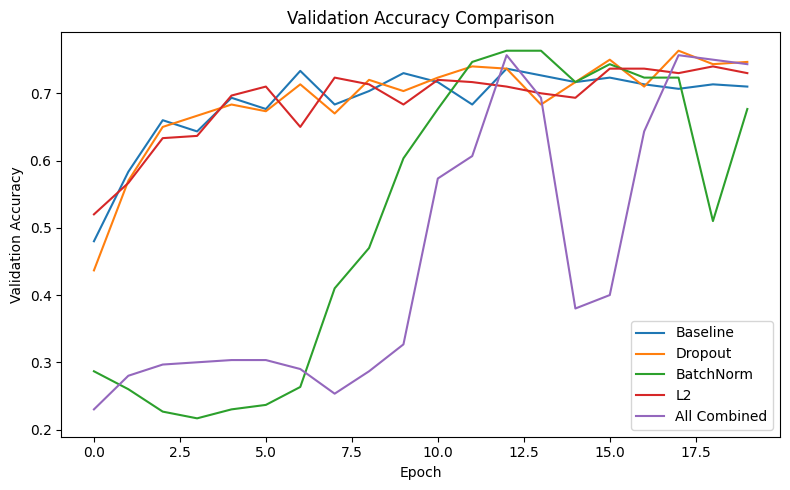

In [7]:
plt.figure(figsize=(8, 5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()